# Training DeBERTa


In [ ]:
# 1. Environment Setup & Imports
import os
import sys

# Auto-detect if running on Google Colab or Local
IN_COLAB = 'google.colab' in sys.modules or 'google.colab' in str(globals())
if IN_COLAB:
    !pip install -q transformers sentencepiece joblib
    from google.colab import drive
    print('Mounting Google Drive...')
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/NLP_Project'
else:
  BASE_DIR = '../..'

DATASET_PATH = os.path.join(BASE_DIR, 'ai_model', 'datasets', 'final_dataset.csv')
SAVE_DIR     = os.path.join(BASE_DIR, 'saved_models')
CKPT_DIR     = os.path.join(SAVE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

import torch
import torch.nn as nn
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import joblib
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, AutoConfig

warnings.filterwarnings('ignore')
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = torch.cuda.is_available()

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

set_seed(SEED)
print(f'Device: {DEVICE}')
print(f'Dataset path resolved: {DATASET_PATH}')
print(f'Model weights save directory: {SAVE_DIR}')


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Dataset path resolved: final_dataset.csv
Model weights save directory: /content/drive/MyDrive/NLP_Project/saved_models


In [ ]:
# 2. Text Preprocessing Function
def clean(text: str, lower: bool = True) -> str:
    if not isinstance(text, str): return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower() if lower else text


In [ ]:
# 3. Load & Split Dataset
print('Loading dataset...')
df = pd.read_csv(DATASET_PATH)
print(f'Dataset loaded. Shape: {df.shape}')

y = df['fake_news_label'].values
idx = np.arange(len(df))

# Split: 70/15/15 stratified by Fake/Real
idx_train, idx_temp = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=SEED)

print(f'Split summary: Train={len(idx_train)} | Val={len(idx_val)} | Test={len(idx_test)}')


Loading dataset...
Dataset loaded. Shape: (26000, 6)
Split summary: Train=18200 | Val=3900 | Test=3900


In [ ]:
# 4. Checkpoint Loading & Saving Functions
def save_ckpt(model, opt, sched, scaler, ep, joint_f1, hist, name):
    ckpt_path = os.path.join(CKPT_DIR, f'{name}_ckpt.pt')
    torch.save({
        'epoch': ep,
        'model_state': model.state_dict(),
        'opt_state': opt.state_dict() if opt else None,
        'sched_state': sched.state_dict() if sched else None,
        'scaler_state': scaler.state_dict() if scaler else None,
        'best_f1': joint_f1,
        'hist': hist
    }, ckpt_path)
    print(f'Checkpoint saved to {ckpt_path}')

def load_ckpt(model, opt, sched, scaler, name):
    ckpt_path = os.path.join(CKPT_DIR, f'{name}_ckpt.pt')
    if os.path.exists(ckpt_path):
        print(f'Loading checkpoint from {ckpt_path}...')
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        if opt and ckpt.get('opt_state'):
            opt.load_state_dict(ckpt['opt_state'])
        if sched and ckpt.get('sched_state'):
            sched.load_state_dict(ckpt['sched_state'])
        if scaler and ckpt.get('scaler_state'):
            scaler.load_state_dict(ckpt['scaler_state'])
        return ckpt['epoch'], ckpt['best_f1'], ckpt['hist']
    else:
        print(f'No checkpoint found at {ckpt_path}. Starting from scratch.')
        return 0, 0.0, {
            'tl': [], 'ta_v': [], 'ta_o': [],
            'vl': [], 'va_v': [], 'va_o': [],
            'vf1_v': [], 'vf1_o': [], 'vf1_j': []
        }


## Config & Dataset Class


In [ ]:
CFG_DEBERTA = dict(
    model_name='microsoft/deberta-v3-base',
    max_len=512,
    batch_size=8,
    epochs=5,
    lr=1e-5,
    warmup=100,
    patience=2,
    accum_steps=4
)

class TransformerMTLDataset(Dataset):
    def __init__(self, df_idx, tokenizer, max_len):
        # Apply text cleaning on the fly
        self.titles = [clean(df['title'].iloc[i], lower=False) for i in df_idx]
        self.texts  = [clean(df['text'].iloc[i], lower=False) for i in df_idx]
        self.y_v  = [df['fake_news_label'].iloc[i] for i in df_idx]
        self.y_o  = [df['ai_label'].iloc[i] for i in df_idx]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.titles)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.titles[idx],
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        return enc, torch.tensor(self.y_v[idx], dtype=torch.long), torch.tensor(self.y_o[idx], dtype=torch.long)


## DataLoaders Setup


In [ ]:
cfg = CFG_DEBERTA
print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(cfg['model_name'])

train_ds = TransformerMTLDataset(idx_train, tokenizer, cfg['max_len'])
val_ds   = TransformerMTLDataset(idx_val, tokenizer, cfg['max_len'])

# num_workers=0 is required for Windows to prevent spawn/multiprocessing errors
train_dl = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True, num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=cfg['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

print('DataLoaders ready.')


Loading tokenizer...
DataLoaders ready.


## Multi-Task Model Definition


In [ ]:
class TransformerMTLClassifier(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h_size = self.encoder.config.hidden_size

        # Classification heads
        self.veracity_head = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(h_size, h_size),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(h_size, 2)
        )
        self.origin_head = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(h_size, h_size),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(h_size, 2)
        )

    def forward(self, **kwargs):
        # Filter out token_type_ids for models that don't use it
        if 'token_type_ids' in kwargs and self.encoder.config.model_type in ['roberta', 'distilroberta']:
            kwargs.pop('token_type_ids', None)

        out = self.encoder(**kwargs)
        # Use CLS token pooling
        cls_rep = out.last_hidden_state[:, 0, :]
        logits_v = self.veracity_head(cls_rep)
        logits_o = self.origin_head(cls_rep)
        return logits_v, logits_o

model = TransformerMTLClassifier(cfg['model_name']).to(DEVICE)
# Explicitly convert model to float32 to ensure GradScaler works as intended
# autocast will handle casting to float16 for forward pass operations
if USE_FP16:
    model = model.float()
print('Model loaded.')


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


## Training Loop with AMP FP16 and Gradient Accumulation


In [ ]:
def train_transformer_mtl(model, train_dl, val_dl, cfg, name):
    crit = nn.CrossEntropyLoss()
    opt  = AdamW(model.parameters(), lr=cfg['lr'], weight_decay=0.01)

    accum = cfg['accum_steps']
    # Calculate total effective optimization steps
    effective_steps = (len(train_dl) // accum) * cfg['epochs']
    sched = get_linear_schedule_with_warmup(opt, cfg['warmup'], effective_steps)
    scaler = GradScaler() if USE_FP16 else None

    start_ep, best_f1, hist = load_ckpt(model, opt, sched, scaler, name)
    pat = 0

    for ep in range(start_ep + 1, cfg['epochs'] + 1):
        model.train()
        tl = 0
        tc_v, tc_o = 0, 0
        tt = 0

        opt.zero_grad()
        for i, batch in enumerate(tqdm(train_dl, desc=f'{name} Ep {ep}')):
            enc, y_v, y_o = batch
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            y_v, y_o = y_v.to(DEVICE), y_o.to(DEVICE)

            with autocast(enabled=USE_FP16):
                logits_v, logits_o = model(**enc)
                loss_v = crit(logits_v, y_v)
                loss_o = crit(logits_o, y_o)
                # Normalize loss to account for gradient accumulation
                loss = (loss_v + loss_o) / accum

            if scaler:
                scaler.scale(loss).backward()
                if (i + 1) % accum == 0 or (i + 1) == len(train_dl):
                    scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(opt)
                    scaler.update()
                    opt.zero_grad()
                    sched.step()
            else:
                loss.backward()
                if (i + 1) % accum == 0 or (i + 1) == len(train_dl):
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    opt.step()
                    opt.zero_grad()
                    sched.step()

            tl += (loss_v.item() + loss_o.item()) * len(y_v)
            tc_v += (logits_v.argmax(1) == y_v).sum().item()
            tc_o += (logits_o.argmax(1) == y_o).sum().item()
            tt += len(y_v)

        # Validation
        model.eval()
        vc_v, vc_o = 0, 0
        vt = 0
        vpr_v, vpr_o = [], []
        vtrue_v, vtrue_o = [], []
        vl_total = 0

        with torch.no_grad():
            for batch in val_dl:
                enc, y_v, y_o = batch
                enc = {k: v.to(DEVICE) for k, v in enc.items()}
                y_v, y_o = y_v.to(DEVICE), y_o.to(DEVICE)

                logits_v, logits_o = model(**enc)
                loss_v = crit(logits_v, y_v)
                loss_o = crit(logits_o, y_o)
                loss = loss_v + loss_o

                vl_total += loss.item() * len(y_v)
                vc_v += (logits_v.argmax(1) == y_v).sum().item()
                vc_o += (logits_o.argmax(1) == y_o).sum().item()
                vt += len(y_v)

                vpr_v.extend(logits_v.argmax(1).cpu().numpy())
                vpr_o.extend(logits_o.argmax(1).cpu().numpy())
                vtrue_v.extend(y_v.cpu().numpy())
                vtrue_o.extend(y_o.cpu().numpy())

        ta_v, ta_o = tc_v / tt, tc_o / tt
        va_v, va_o = vc_v / vt, vc_o / vt

        f1_v = f1_score(vtrue_v, vpr_v, average='macro', zero_division=0)
        f1_o = f1_score(vtrue_o, vpr_o, average='macro', zero_division=0)
        f1_j = (f1_v + f1_o) / 2.0

        hist['tl'].append(tl / tt)
        hist['ta_v'].append(ta_v)
        hist['ta_o'].append(ta_o)
        hist['vl'].append(vl_total / vt)
        hist['va_v'].append(va_v)
        hist['va_o'].append(va_o)
        hist['vf1_v'].append(f1_v)
        hist['vf1_o'].append(f1_o)
        hist['vf1_j'].append(f1_j)

        print(f'Epoch {ep:02d} | TrainLoss: {tl/tt:.4f} | ValLoss: {vl_total/vt:.4f}')
        print(f'         Veracity Acc: {va_v:.4f} F1: {f1_v:.4f} | Origin Acc: {va_o:.4f} F1: {f1_o:.4f} | Joint F1: {f1_j:.4f}')

        # Save checkpoint to drive
        save_ckpt(model, opt, sched, scaler, ep, f1_j, hist, name)

        # Save best weights
        if f1_j > best_f1:
            best_f1 = f1_j
            pat = 0
            best_path = os.path.join(SAVE_DIR, f'{name}_best.pt')
            torch.save(model.state_dict(), best_path)
            print(f'  👉 New best Joint F1: {f1_j:.4f}. Saved weights to {best_path}')
        else:
            pat += 1
            print(f'  Patience: {pat}/{cfg["patience"]}')
            if pat >= cfg['patience']:
                print('Early stopping triggered!')
                break

    # Save tokenizer
    tok_save_path = os.path.join(SAVE_DIR, f'{name}_tokenizer')
    tokenizer.save_pretrained(tok_save_path)
    print(f'Tokenizer saved to {tok_save_path}')

    best_path = os.path.join(SAVE_DIR, f'{name}_best.pt')
    sd = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(sd)
    return hist


In [ ]:
hist = train_transformer_mtl(model, train_dl, val_dl, cfg, 'deberta')


Loading checkpoint from /content/drive/MyDrive/NLP_Project/saved_models/checkpoints/deberta_ckpt.pt...
Tokenizer saved to /content/drive/MyDrive/NLP_Project/saved_models/deberta_tokenizer


## Plot Training History


In [ ]:
# Plot history function
def plot_history(hist, name):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    eps = range(1, len(hist['tl'])+1)

    # Loss
    axes[0, 0].plot(eps, hist['tl'], label='Train Loss', color='royalblue', linewidth=2)
    axes[0, 0].plot(eps, hist['vl'], label='Val Loss',   color='crimson',   linewidth=2, linestyle='--')
    axes[0, 0].set_title(f'{name} – Loss per Epoch', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].legend()

    # Veracity Accuracy (Train vs Val)
    axes[0, 1].plot(eps, hist['ta_v'], label='Train Veracity Acc', color='royalblue', linewidth=2)
    axes[0, 1].plot(eps, hist['va_v'], label='Val Veracity Acc',   color='teal',      linewidth=2, linestyle='--')
    axes[0, 1].set_title(f'{name} – Veracity Accuracy', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy'); axes[0, 1].legend()
    axes[0, 1].set_ylim(0, 1)

    # Origin Accuracy (Train vs Val)
    axes[0, 2].plot(eps, hist['ta_o'], label='Train Origin Acc', color='royalblue',  linewidth=2)
    axes[0, 2].plot(eps, hist['va_o'], label='Val Origin Acc',   color='darkorange', linewidth=2, linestyle='--')
    axes[0, 2].set_title(f'{name} – Origin Accuracy', fontweight='bold')
    axes[0, 2].set_xlabel('Epoch'); axes[0, 2].set_ylabel('Accuracy'); axes[0, 2].legend()
    axes[0, 2].set_ylim(0, 1)

    # Veracity F1
    axes[1, 0].plot(eps, hist['vf1_v'], label='Val Veracity F1', color='teal',       linewidth=2)
    axes[1, 0].set_title(f'{name} – Veracity Macro F1', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Macro F1'); axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 1)

    # Origin F1
    axes[1, 1].plot(eps, hist['vf1_o'], label='Val Origin F1', color='darkorange', linewidth=2)
    axes[1, 1].set_title(f'{name} – Origin Macro F1', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Macro F1'); axes[1, 1].legend()
    axes[1, 1].set_ylim(0, 1)

    # Joint F1
    axes[1, 2].plot(eps, hist['vf1_j'], label='Val Joint F1', color='forestgreen', linewidth=2.5)
    axes[1, 2].set_title(f'{name} – Joint Macro F1', fontweight='bold')
    axes[1, 2].set_xlabel('Epoch'); axes[1, 2].set_ylabel('Macro F1'); axes[1, 2].legend()
    axes[1, 2].set_ylim(0, 1)

    plt.suptitle(f'{name} Training History', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{name}_history.png'), bbox_inches='tight')
    plt.show()


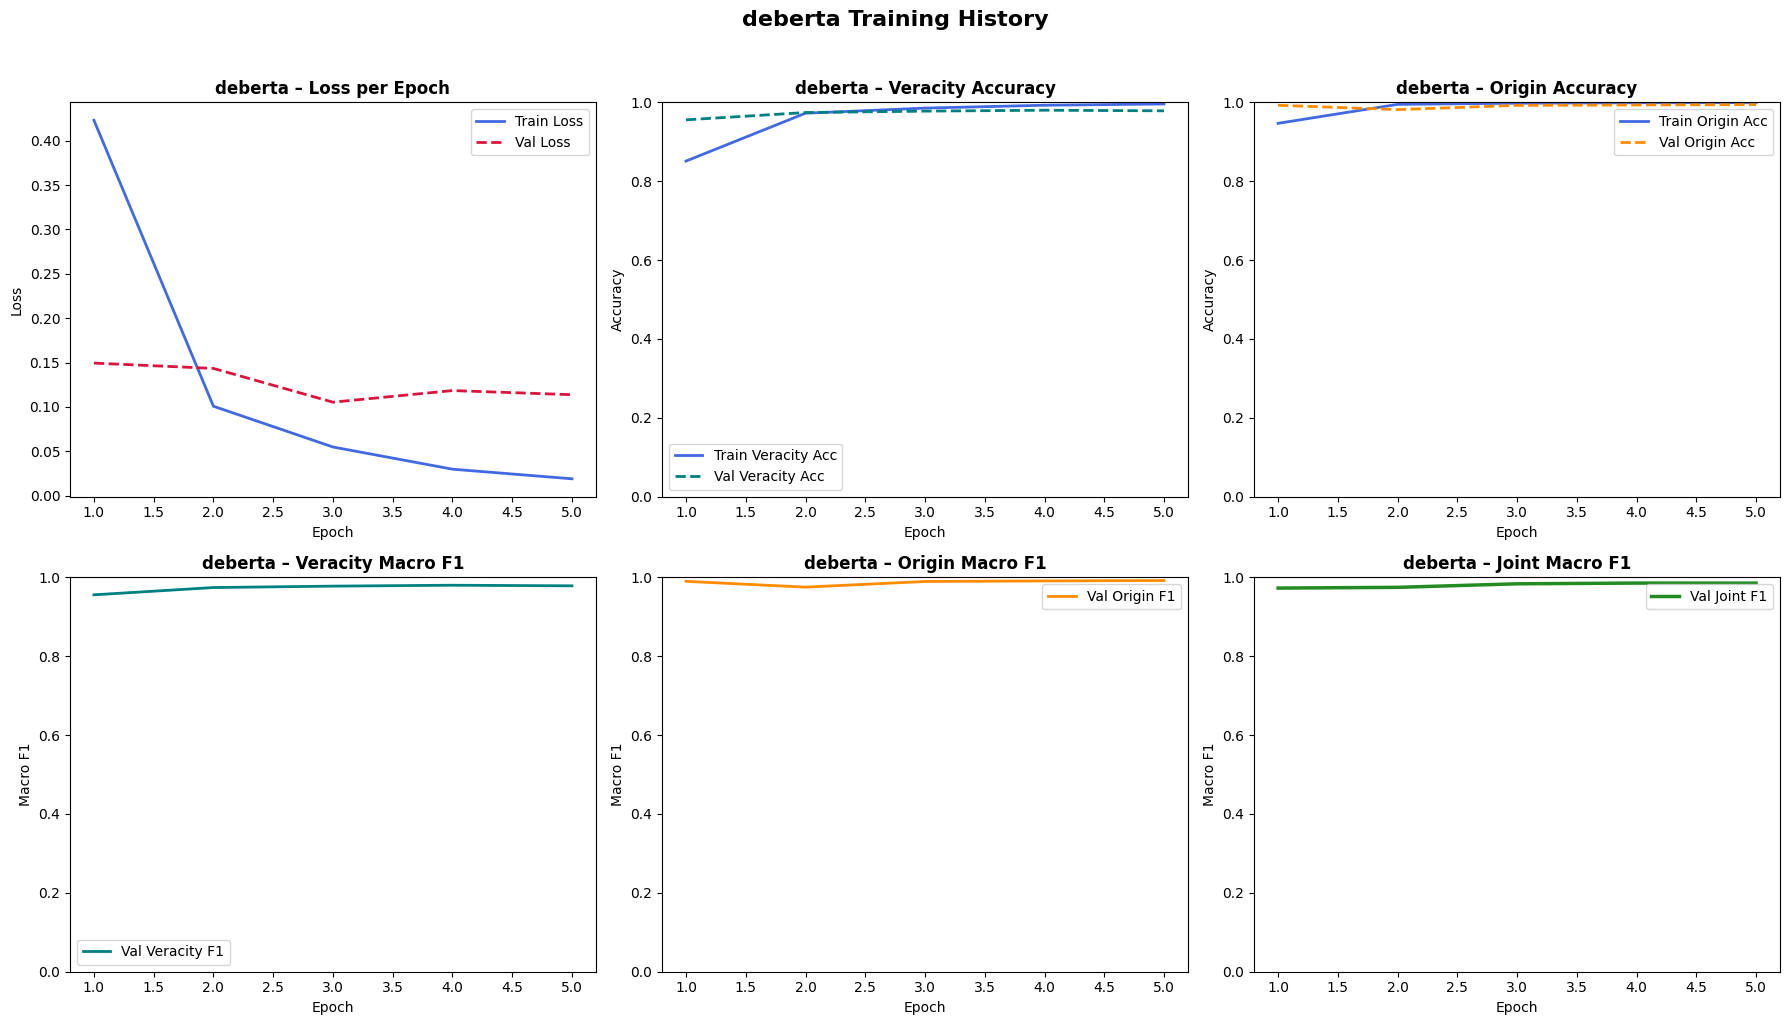

In [ ]:
plot_history(hist, 'deberta')


## Predict on Validation Set & Plot Metrics


In [ ]:
# Plot evaluation metrics function
def plot_metrics(true_v, pred_v, true_o, pred_o, probs_v, probs_o, name, split='Test'):
    from sklearn.metrics import (
        confusion_matrix, roc_curve, roc_auc_score,
        accuracy_score, precision_score, recall_score, f1_score)
    import seaborn as sns

    acc_v  = accuracy_score(true_v, pred_v)
    prec_v = precision_score(true_v, pred_v, average='macro', zero_division=0)
    rec_v  = recall_score(true_v, pred_v, average='macro', zero_division=0)
    f1_v   = f1_score(true_v, pred_v, average='macro', zero_division=0)
    auc_v  = roc_auc_score(true_v, probs_v)

    acc_o  = accuracy_score(true_o, pred_o)
    prec_o = precision_score(true_o, pred_o, average='macro', zero_division=0)
    rec_o  = recall_score(true_o, pred_o, average='macro', zero_division=0)
    f1_o   = f1_score(true_o, pred_o, average='macro', zero_division=0)
    auc_o  = roc_auc_score(true_o, probs_o)

    print(f"\n{'='*62}")
    print(f"  {split} Set Metrics - {name}")
    print(f"{'='*62}")
    print(f"{'Task':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
    print(f"{'-'*62}")
    print(f"{'Veracity (Fake/Real)':<22} {acc_v:>9.4f} {prec_v:>10.4f} {rec_v:>8.4f} {f1_v:>8.4f} {auc_v:>8.4f}")
    print(f"{'Origin (Human/AI)':<22} {acc_o:>9.4f} {prec_o:>10.4f} {rec_o:>8.4f} {f1_o:>8.4f} {auc_o:>8.4f}")
    print(f"{'='*62}")
    print(f"Joint Macro F1: {(f1_v + f1_o) / 2:.4f}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    cm_v = confusion_matrix(true_v, pred_v)
    sns.heatmap(cm_v, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=['Fake (0)', 'Real (1)'], yticklabels=['Fake (0)', 'Real (1)'],
                annot_kws={'size': 14})
    axes[0, 0].set_title(f'Veracity Confusion Matrix ({split})', fontweight='bold')
    axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')

    cm_o = confusion_matrix(true_o, pred_o)
    sns.heatmap(cm_o, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
                xticklabels=['Human (0)', 'AI (1)'], yticklabels=['Human (0)', 'AI (1)'],
                annot_kws={'size': 14})
    axes[0, 1].set_title(f'Origin Confusion Matrix ({split})', fontweight='bold')
    axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')

    metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
    metrics_v = [acc_v, prec_v, rec_v, f1_v, auc_v]
    metrics_o = [acc_o, prec_o, rec_o, f1_o, auc_o]
    x = np.arange(len(metrics_labels))
    width = 0.35
    axes[0, 2].bar(x - width/2, metrics_v, width, label='Veracity', color='steelblue',  alpha=0.85)
    axes[0, 2].bar(x + width/2, metrics_o, width, label='Origin',   color='darkorange', alpha=0.85)
    axes[0, 2].set_title(f'Metrics Summary ({split})', fontweight='bold')
    axes[0, 2].set_xticks(x); axes[0, 2].set_xticklabels(metrics_labels)
    axes[0, 2].set_ylim(0, 1.05); axes[0, 2].legend(); axes[0, 2].set_ylabel('Score')
    for i, (v, o) in enumerate(zip(metrics_v, metrics_o)):
        axes[0, 2].text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
        axes[0, 2].text(i + width/2, o + 0.01, f'{o:.3f}', ha='center', va='bottom', fontsize=8)

    fpr_v, tpr_v, _ = roc_curve(true_v, probs_v)
    axes[1, 0].plot(fpr_v, tpr_v, color='teal', linewidth=2, label=f'AUC = {auc_v:.4f}')
    axes[1, 0].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1, 0].set_title(f'Veracity ROC Curve ({split})', fontweight='bold')
    axes[1, 0].set_xlabel('False Positive Rate'); axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].legend()

    fpr_o, tpr_o, _ = roc_curve(true_o, probs_o)
    axes[1, 1].plot(fpr_o, tpr_o, color='darkorange', linewidth=2, label=f'AUC = {auc_o:.4f}')
    axes[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1, 1].set_title(f'Origin ROC Curve ({split})', fontweight='bold')
    axes[1, 1].set_xlabel('False Positive Rate'); axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].legend()

    cm_v_norm = cm_v.astype('float') / cm_v.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_v_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1, 2],
                xticklabels=['Fake (0)', 'Real (1)'], yticklabels=['Fake (0)', 'Real (1)'],
                annot_kws={'size': 12})
    axes[1, 2].set_title(f'Veracity CM – Normalised ({split})', fontweight='bold')
    axes[1, 2].set_xlabel('Predicted'); axes[1, 2].set_ylabel('Actual')

    plt.suptitle(f'{name} – {split} Set Evaluation', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{name}_{split.lower()}_plots.png'), bbox_inches='tight')
    plt.show()

    return {
        'veracity': {'acc': acc_v, 'prec': prec_v, 'rec': rec_v, 'f1': f1_v, 'auc': auc_v},
        'origin':   {'acc': acc_o, 'prec': prec_o, 'rec': rec_o, 'f1': f1_o, 'auc': auc_o},
        'joint_f1': (f1_v + f1_o) / 2
    }


[+] test_dl created.
[+] Loaded best model from /content/drive/MyDrive/NLP_Project/saved_models/deberta_best.pt
Evaluating on Validation Set...
  Avg. inference time per sample: 3.800 ms

  Validation Set Metrics — deberta
Task                    Accuracy  Precision   Recall       F1      AUC
--------------------------------------------------------------
Veracity (Fake/Real)      0.9800     0.9800   0.9800   0.9800   0.9974
Origin (Human/AI)         0.9933     0.9873   0.9945   0.9909   0.9997
Joint Macro F1: 0.9854


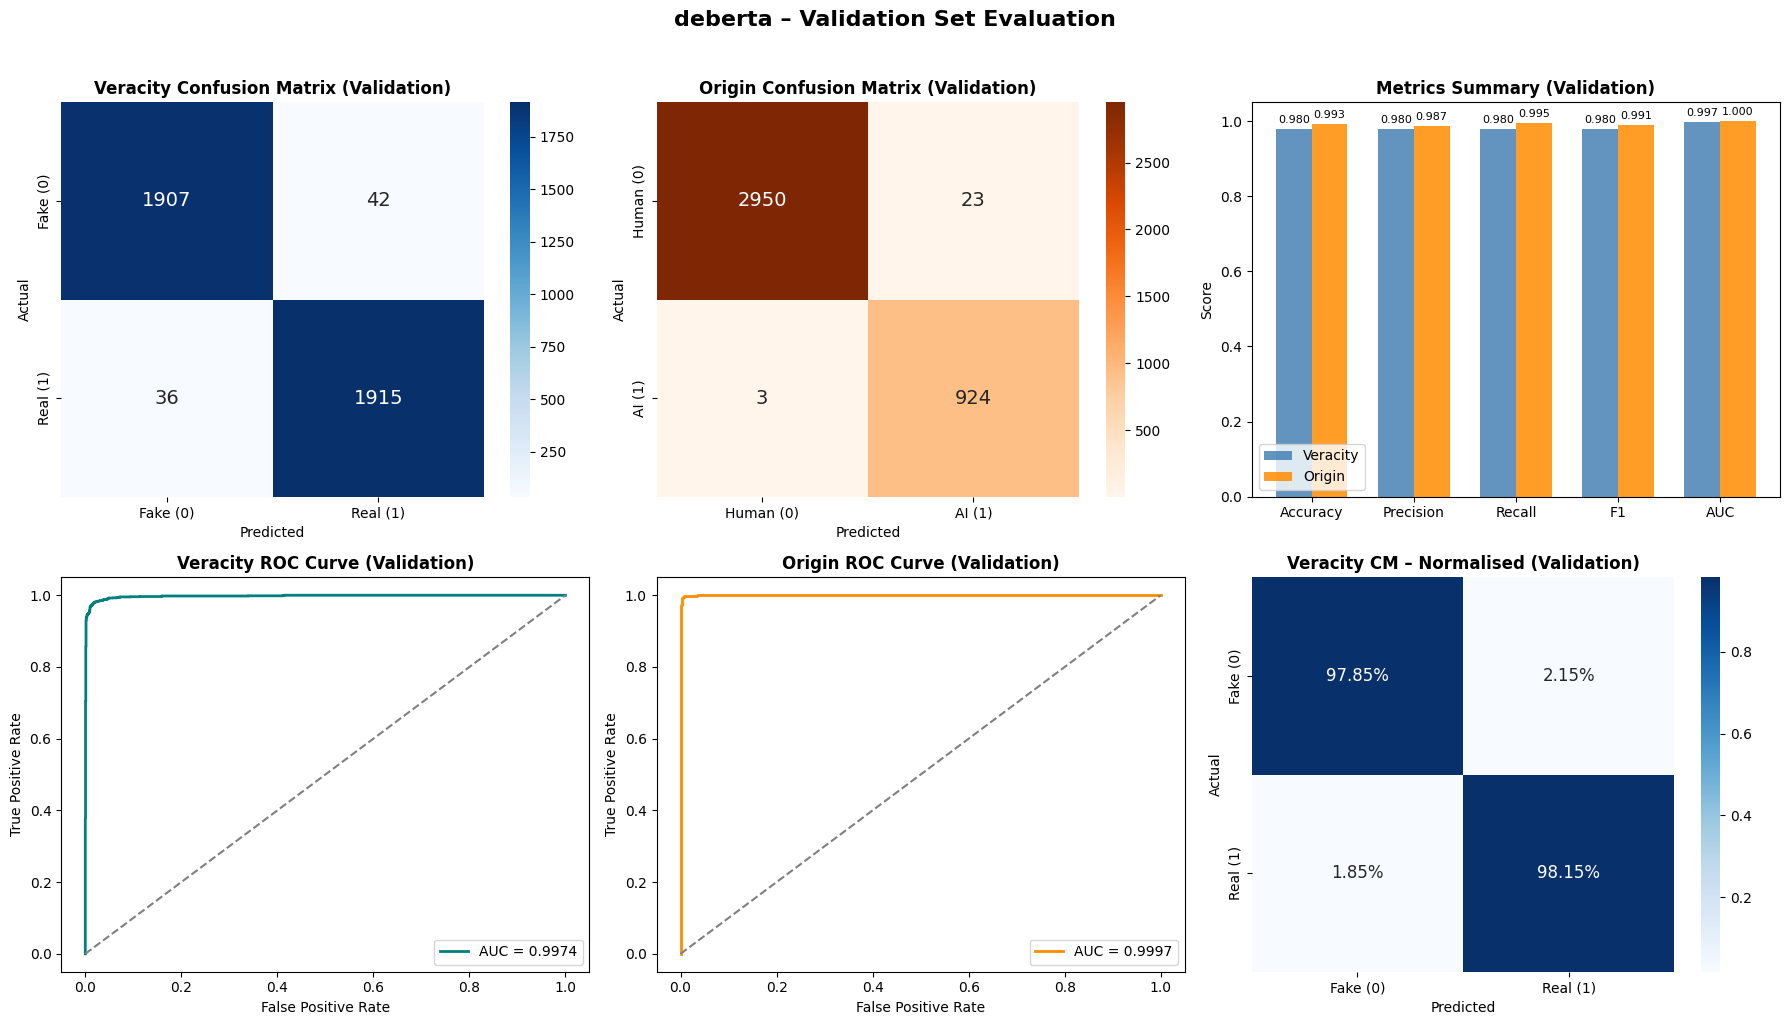


Evaluating on Test Set...
  Avg. inference time per sample: 3.361 ms

  Test Set Metrics — deberta
Task                    Accuracy  Precision   Recall       F1      AUC
--------------------------------------------------------------
Veracity (Fake/Real)      0.9836     0.9836   0.9836   0.9836   0.9980
Origin (Human/AI)         0.9936     0.9885   0.9939   0.9912   0.9989
Joint Macro F1: 0.9874


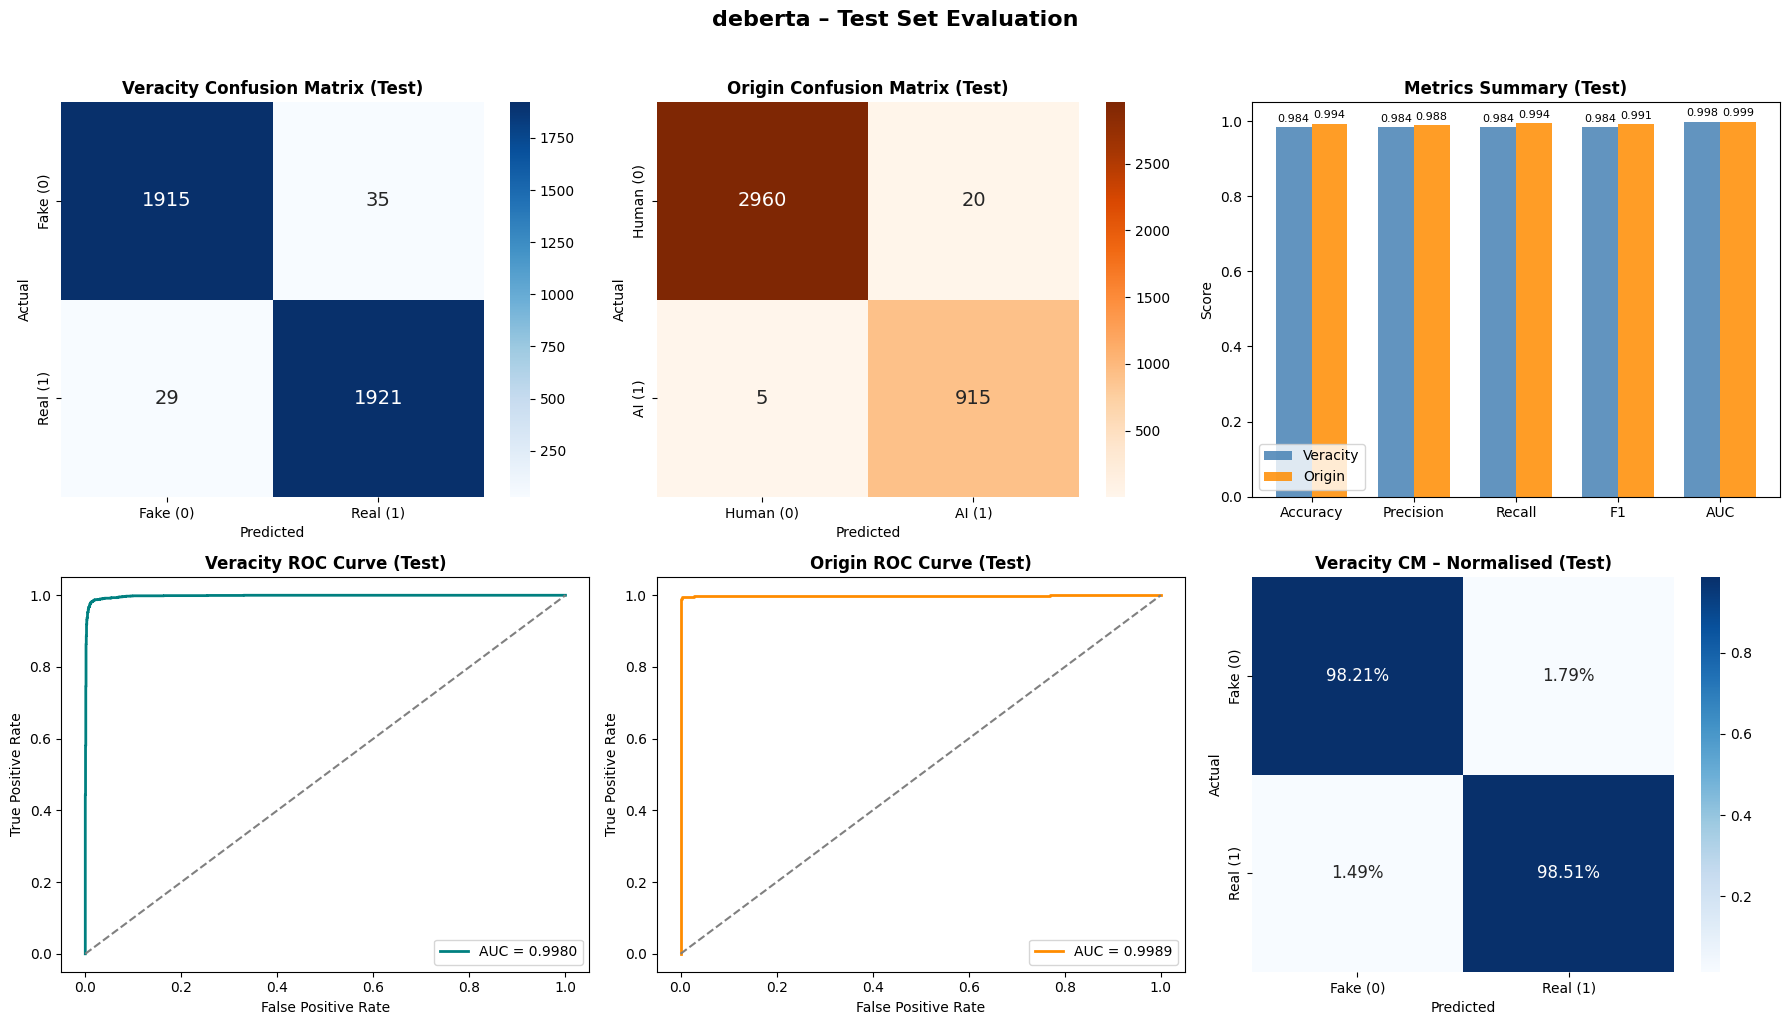


  Val vs Test Comparison — deberta
Task / Metric                    Validation         Test   Δ (Test-Val)
----------------------------------------------------------------------
Veracity ACC                         0.9800       0.9836 ▲       0.0036
Veracity PREC                        0.9800       0.9836 ▲       0.0036
Veracity REC                         0.9800       0.9836 ▲       0.0036
Veracity F1                          0.9800       0.9836 ▲       0.0036
Veracity AUC                         0.9974       0.9980 ▲       0.0006
Origin ACC                           0.9933       0.9936 ▲       0.0003
Origin PREC                          0.9873       0.9885 ▲       0.0011
Origin REC                           0.9945       0.9939 ▼       0.0006
Origin F1                            0.9909       0.9912 ▲       0.0003
Origin AUC                           0.9997       0.9989 ▼       0.0008
----------------------------------------------------------------------
Joint Macro F1                

In [ ]:
# Create test_dl if not already in memory (e.g. if DataLoader cell wasn't re-run)
if 'test_dl' not in dir():
    test_ds = TransformerMTLDataset(idx_test, tokenizer, cfg['max_len'])
    test_dl = DataLoader(test_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
    print('[+] test_dl created.')

import time

# Load best model weights
best_path = os.path.join(SAVE_DIR, 'deberta_best.pt')
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    print(f'[+] Loaded best model from {best_path}')
else:
    print('[!] Best model not found. Using current model state.')

model.eval()

def run_eval(dl):
    tv, pv, prv = [], [], []
    to, po, pro = [], [], []
    t_total, n = 0.0, 0
    with torch.no_grad():
        for batch in dl:
            enc, y_v, y_o = batch
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            t0 = time.perf_counter()
            logits_v, logits_o = model(**enc)
            t_total += time.perf_counter() - t0
            n += len(y_v)
            tv.extend(y_v.numpy())
            pv.extend(logits_v.argmax(1).cpu().numpy())
            prv.extend(torch.softmax(logits_v, dim=1)[:, 1].cpu().numpy())
            to.extend(y_o.numpy())
            po.extend(logits_o.argmax(1).cpu().numpy())
            pro.extend(torch.softmax(logits_o, dim=1)[:, 1].cpu().numpy())
    inf_ms = (t_total / n) * 1000
    print(f'  Avg. inference time per sample: {inf_ms:.3f} ms')
    return tv, pv, prv, to, po, pro

print('Evaluating on Validation Set...')
tv, pv, prv, to, po, pro = run_eval(val_dl)
val_m = plot_metrics(tv, pv, to, po, prv, pro, 'deberta', split='Validation')

print('\nEvaluating on Test Set...')
tv, pv, prv, to, po, pro = run_eval(test_dl)
test_m = plot_metrics(tv, pv, to, po, prv, pro, 'deberta', split='Test')

# ── Val vs Test Comparison ──────────────────────────────────────
print(f"\n{'='*70}")
print(f"  Val vs Test Comparison - deberta")
print(f"{'='*70}")
print(f"{'Task / Metric':<30} {'Validation':>12} {'Test':>12} {chr(916)+' (Test-Val)':>14}")
print(f"{'-'*70}")
for task, tk in [('Veracity', 'veracity'), ('Origin', 'origin')]:
    for metric in ['acc', 'prec', 'rec', 'f1', 'auc']:
        v = val_m[tk][metric]; t = test_m[tk][metric]; d = t - v
        print(f"{f'{task} {metric.upper()}':<30} {v:>12.4f} {t:>12.4f} {chr(9650) if d >= 0 else chr(9660)} {abs(d):>12.4f}")
print(f"{'-'*70}")
j_v = val_m['joint_f1']; j_t = test_m['joint_f1']; j_d = j_t - j_v
print(f"{'Joint Macro F1':<30} {j_v:>12.4f} {j_t:>12.4f} {chr(9650) if j_d >= 0 else chr(9660)} {abs(j_d):>12.4f}")
print(f"{'='*70}")
